In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

df = pd.read_csv("../data/anomaly_results.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Time range:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

Dataset shape: (8647, 72)
Time range:
2024-01-01 00:00:00 to 2024-12-31 23:00:00


In [2]:
required_columns = [
    "timestamp",
    "temp",
    "rhum",
    "prcp",
    "wdir",
    "wspd",
    "pres",
    "cldc",
    "coco"
]

missing_columns = [
    c for c in required_columns
    if c not in df.columns
]

print("Missing required columns:", missing_columns)

assert len(missing_columns) == 0, (
    f"Missing columns: {missing_columns}"
)

print("VALIDATION PASSED")

Missing required columns: []
VALIDATION PASSED


In [3]:
sensor_columns = [
    "temp",
    "rhum",
    "wspd",
    "pres"
]

In [4]:
clean_mask = (
    df[sensor_columns].notna().all(axis=1)
)

if "rule_anomaly" in df.columns:
    clean_mask &= ~df["rule_anomaly"]

if "candidate_anomaly" in df.columns:
    clean_mask &= ~df["candidate_anomaly"]

clean_df = (
    df.loc[clean_mask]
    .copy()
    .reset_index(drop=True)
)

print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print(
    "Removed rows:",
    len(df) - len(clean_df)
)

Original rows: 8647
Clean rows: 8548
Removed rows: 99


In [5]:
assert clean_df[sensor_columns].isna().sum().sum() == 0

if "rule_anomaly" in clean_df.columns:
    assert clean_df["rule_anomaly"].sum() == 0

print("VALIDATION PASSED: clean source contains no missing core sensor values.")

VALIDATION PASSED: clean source contains no missing core sensor values.


In [6]:
time_diff = (
    clean_df["timestamp"]
    .diff()
    .dropna()
)

print(time_diff.value_counts().head(10))

timestamp
0 days 01:00:00    8516
0 days 02:00:00      29
7 days 06:00:00       1
1 days 11:00:00       1
Name: count, dtype: int64


In [7]:
hourly_fraction = (
    time_diff == pd.Timedelta(hours=1)
).mean()

print(
    "Fraction of consecutive rows exactly 1 hour apart:",
    round(hourly_fraction * 100, 2),
    "%"
)

Fraction of consecutive rows exactly 1 hour apart: 99.64 %


In [8]:
WINDOW_SIZE = 24

valid_starts = []

timestamps = clean_df["timestamp"].to_numpy()

for i in range(
    len(clean_df) - WINDOW_SIZE + 1
):
    
    window_times = clean_df.loc[
        i:i + WINDOW_SIZE - 1,
        "timestamp"
    ]
    
    expected = pd.date_range(
        start=window_times.iloc[0],
        periods=WINDOW_SIZE,
        freq="h"
    )
    
    if window_times.reset_index(drop=True).equals(
        pd.Series(expected, name="timestamp")
    ):
        valid_starts.append(i)

print("Valid 24-hour windows:", len(valid_starts))

Valid 24-hour windows: 7923


In [9]:
assert len(valid_starts) > 0, (
    "No valid 24-hour windows found."
)

print("VALIDATION PASSED")

VALIDATION PASSED


In [10]:
def robust_scale(series):
    series = series.dropna()
    
    median = series.median()
    
    mad = np.median(
        np.abs(series - median)
    )
    
    scale = 1.4826 * mad
    
    # Safety fallback if MAD is zero
    if not np.isfinite(scale) or scale == 0:
        scale = series.std()
    
    if not np.isfinite(scale) or scale == 0:
        scale = 1.0
    
    return float(scale)


sensor_scales = {
    col: robust_scale(clean_df[col])
    for col in sensor_columns
}

sensor_scales

{'temp': 2.5204199999999988,
 'rhum': 16.3086,
 'wspd': 10.08168,
 'pres': 3.558239999999966}

In [11]:
for sensor, scale in sensor_scales.items():
    assert np.isfinite(scale)
    assert scale > 0

print("VALIDATION PASSED")

VALIDATION PASSED


In [19]:
def inject_fault(
    data,
    sensor,
    start_idx,
    end_idx,
    fault_type,
    magnitude=None
):
    
    out = data.copy(deep=True)

    # ------------------------------------------------
    # IMPORTANT:
    # Convert the selected sensor to float before
    # injecting decimal-valued faults.
    # ------------------------------------------------
    out[sensor] = pd.to_numeric(
        out[sensor],
        errors="coerce"
    ).astype(float)

    if not (
        0 <= start_idx < end_idx <= len(out)
    ):
        raise ValueError(
            "Invalid fault window."
        )

    idx = out.index[start_idx:end_idx]

    scale = robust_scale(out[sensor])

    if magnitude is None:

        magnitude_map = {
            "spike": 6 * scale,
            "bias": 3 * scale,
            "drift": 4 * scale
        }

        magnitude = magnitude_map.get(
            fault_type,
            0
        )

    # ------------------------------------------------
    # SPIKE
    # ------------------------------------------------
    if fault_type == "spike":

        k = min(3, len(idx))

        out.loc[
            idx[:k],
            sensor
        ] = (
            out.loc[idx[:k], sensor]
            + magnitude
        )

    # ------------------------------------------------
    # BIAS
    # ------------------------------------------------
    elif fault_type == "bias":

        out.loc[
            idx,
            sensor
        ] = (
            out.loc[idx, sensor]
            + magnitude
        )

    # ------------------------------------------------
    # DRIFT
    # ------------------------------------------------
    elif fault_type == "drift":

        drift_values = np.linspace(
            0,
            magnitude,
            len(idx)
        )

        out.loc[
            idx,
            sensor
        ] = (
            out.loc[idx, sensor].to_numpy()
            + drift_values
        )

    # ------------------------------------------------
    # STUCK SENSOR
    # ------------------------------------------------
    elif fault_type == "stuck_sensor":

        constant_value = float(
            out.loc[idx[0], sensor]
        )

        out.loc[
            idx,
            sensor
        ] = constant_value

    # ------------------------------------------------
    # MISSING
    # ------------------------------------------------
    elif fault_type == "missing":

        out.loc[
            idx,
            sensor
        ] = np.nan

    else:

        raise ValueError(
            f"Unknown fault type: {fault_type}"
        )

    # ------------------------------------------------
    # Ground-truth labels
    # ------------------------------------------------

    out["fault_type"] = "normal"
    out["fault_sensor"] = pd.NA

    out.loc[
        idx,
        "fault_type"
    ] = fault_type

    out.loc[
        idx,
        "fault_sensor"
    ] = sensor

    return out

In [20]:
TEST_START = 100
TEST_END = 124

test_results = {}

for fault in [
    "spike",
    "bias",
    "drift",
    "stuck_sensor",
    "missing"
]:
    
    test_df = inject_fault(
        clean_df,
        sensor="temp",
        start_idx=TEST_START,
        end_idx=TEST_END,
        fault_type=fault
    )
    
    test_results[fault] = test_df
    
    # Correct labels
    assert (
        test_df.loc[
            TEST_START:TEST_END-1,
            "fault_type"
        ] == fault
    ).all()
    
    # Missing fault
    if fault == "missing":
        
        assert (
            test_df.loc[
                TEST_START:TEST_END-1,
                "temp"
            ].isna()
        ).all()
    
    # Stuck sensor
    elif fault == "stuck_sensor":
        
        assert (
            test_df.loc[
                TEST_START:TEST_END-1,
                "temp"
            ].nunique()
            == 1
        )

print(
    "VALIDATION PASSED: "
    "all five fault types."
)

VALIDATION PASSED: all five fault types.


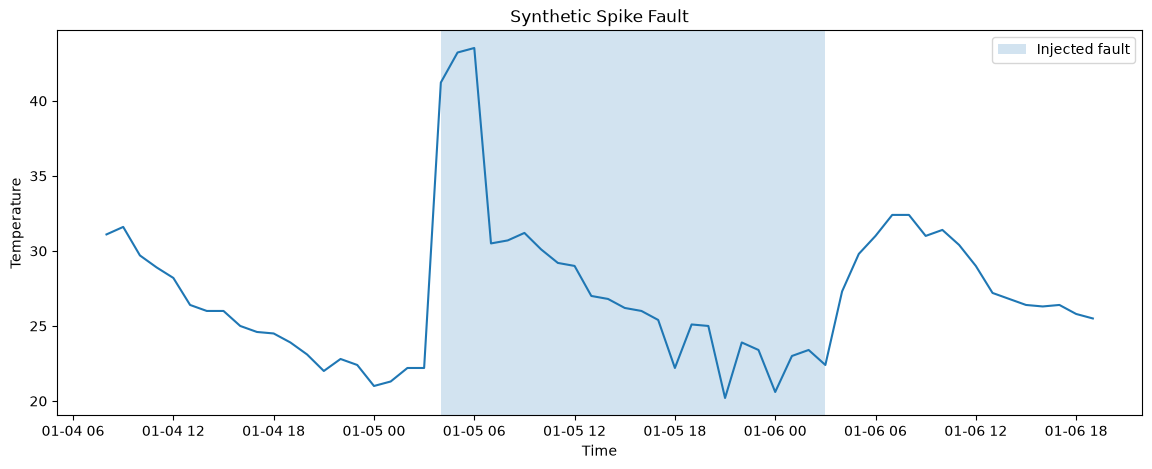

In [21]:
test_spike = test_results["spike"]

plt.figure(figsize=(14, 5))

plt.plot(
    test_spike["timestamp"].iloc[80:140],
    test_spike["temp"].iloc[80:140]
)

plt.axvspan(
    test_spike["timestamp"].iloc[100],
    test_spike["timestamp"].iloc[123],
    alpha=0.2,
    label="Injected fault"
)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Synthetic Spike Fault")
plt.legend()
plt.show()

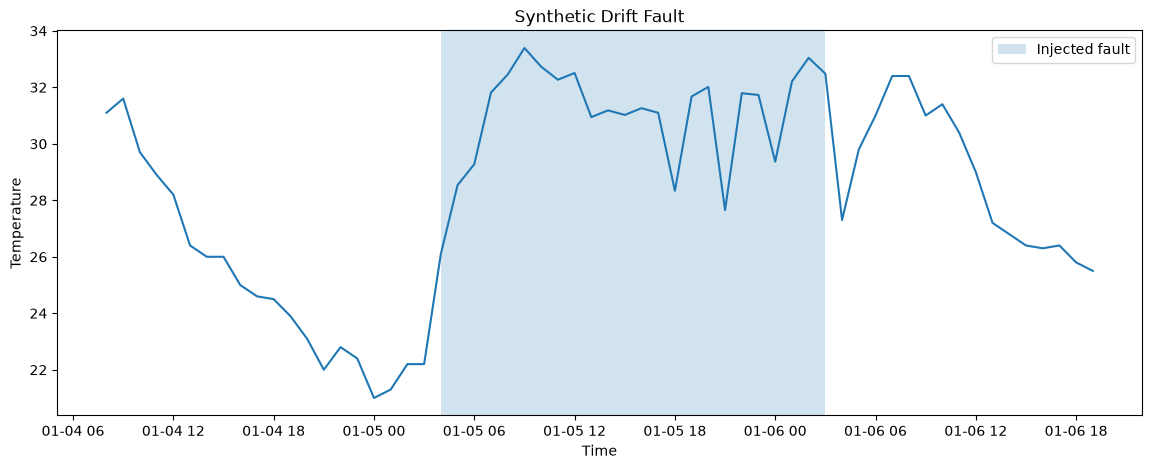

In [22]:
test_drift = test_results["drift"]

plt.figure(figsize=(14, 5))

plt.plot(
    test_drift["timestamp"].iloc[80:140],
    test_drift["temp"].iloc[80:140]
)

plt.axvspan(
    test_drift["timestamp"].iloc[100],
    test_drift["timestamp"].iloc[123],
    alpha=0.2,
    label="Injected fault"
)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Synthetic Drift Fault")
plt.legend()
plt.show()

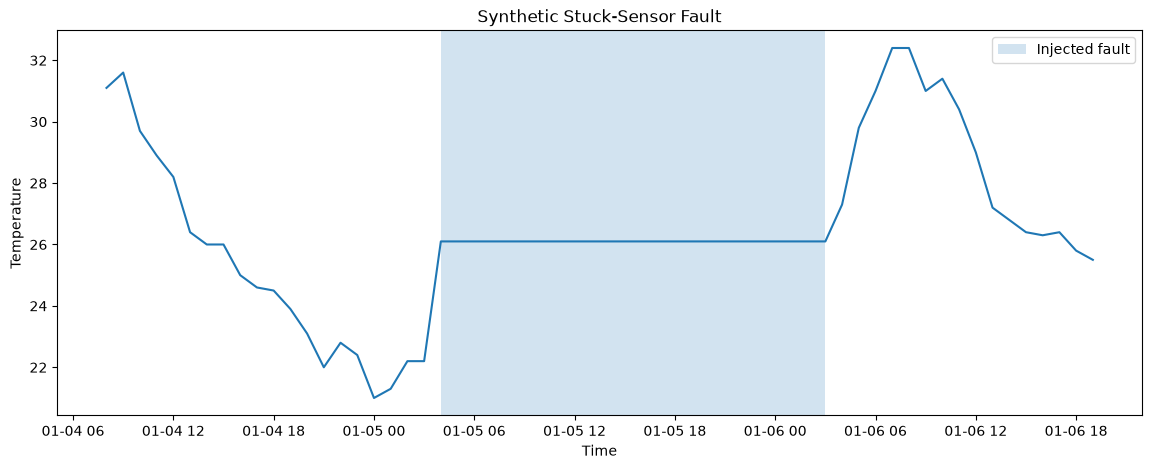

In [23]:
test_stuck = test_results["stuck_sensor"]

plt.figure(figsize=(14, 5))

plt.plot(
    test_stuck["timestamp"].iloc[80:140],
    test_stuck["temp"].iloc[80:140]
)

plt.axvspan(
    test_stuck["timestamp"].iloc[100],
    test_stuck["timestamp"].iloc[123],
    alpha=0.2,
    label="Injected fault"
)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Synthetic Stuck-Sensor Fault")
plt.legend()
plt.show()

In [24]:
RANDOM_SEED = 42

rng = np.random.default_rng(
    RANDOM_SEED
)

N_SCENARIOS_PER_CLASS = 50

required_scenarios = (
    N_SCENARIOS_PER_CLASS * 6
)

print(
    "Scenarios required:",
    required_scenarios
)

print(
    "Available windows:",
    len(valid_starts)
)

assert len(valid_starts) >= required_scenarios, (
    "Not enough valid 24-hour windows."
)

print("VALIDATION PASSED")

Scenarios required: 300
Available windows: 7923
VALIDATION PASSED


In [25]:
fault_types = [
    "normal",
    "spike",
    "bias",
    "drift",
    "stuck_sensor",
    "missing"
]

scenario_starts = rng.choice(
    valid_starts,
    size=required_scenarios,
    replace=False
)

records = []

scenario_id = 0

for fault_type in fault_types:
    
    for _ in range(
        N_SCENARIOS_PER_CLASS
    ):
        
        start_idx = int(
            scenario_starts[scenario_id]
        )
        
        end_idx = (
            start_idx + WINDOW_SIZE
        )
        
        scenario = clean_df.iloc[
            start_idx:end_idx
        ].copy()
        
        # Choose a sensor for fault
        if fault_type == "normal":
            
            sensor = "none"
            
            scenario["fault_type"] = "normal"
            scenario["fault_sensor"] = pd.NA
        
        else:
            
            sensor = rng.choice(
                sensor_columns
            )
            
            scenario = inject_fault(
                scenario,
                sensor=sensor,
                start_idx=0,
                end_idx=len(scenario),
                fault_type=fault_type
            )
        
        scenario["scenario_id"] = (
            scenario_id
        )
        
        records.append(
            scenario
        )
        
        scenario_id += 1

In [26]:
fault_df = pd.concat(
    records,
    ignore_index=True
)

print(
    "Fault dataset shape:",
    fault_df.shape
)

Fault dataset shape: (7200, 75)


In [27]:
print(
    fault_df
    .groupby("fault_type")
    ["scenario_id"]
    .nunique()
)

fault_type
bias            50
drift           50
missing         50
normal          50
spike           50
stuck_sensor    50
Name: scenario_id, dtype: int64


In [28]:
scenario_counts = (
    fault_df
    .groupby("fault_type")
    ["scenario_id"]
    .nunique()
)

for fault in fault_types:
    
    assert (
        scenario_counts[fault]
        == N_SCENARIOS_PER_CLASS
    )

print(
    "VALIDATION PASSED: "
    "all classes balanced."
)

VALIDATION PASSED: all classes balanced.


In [29]:
missing_faults = fault_df[
    fault_df["fault_type"] == "missing"
]

print(
    missing_faults[
        [
            "scenario_id",
            "fault_sensor"
        ]
    ].drop_duplicates()
)

      scenario_id fault_sensor
6000          250         rhum
6024          251         temp
6048          252         rhum
6072          253         wspd
6096          254         pres
6120          255         wspd
6144          256         pres
6168          257         wspd
6192          258         temp
6216          259         rhum
6240          260         pres
6264          261         temp
6288          262         pres
6312          263         wspd
6336          264         rhum
6360          265         pres
6384          266         pres
6408          267         temp
6432          268         temp
6456          269         wspd
6480          270         pres
6504          271         temp
6528          272         wspd
6552          273         temp
6576          274         wspd
6600          275         wspd
6624          276         temp
6648          277         wspd
6672          278         pres
6696          279         pres
6720          280         temp
6744    

In [30]:
for scenario_id in (
    missing_faults["scenario_id"]
    .unique()
):
    
    scenario = missing_faults[
        missing_faults["scenario_id"]
        == scenario_id
    ]
    
    sensor = (
        scenario["fault_sensor"]
        .dropna()
        .iloc[0]
    )
    
    assert (
        scenario[sensor].isna().all()
    )

print(
    "VALIDATION PASSED: "
    "missing faults correctly injected."
)

VALIDATION PASSED: missing faults correctly injected.


In [31]:
stuck_faults = fault_df[
    fault_df["fault_type"]
    == "stuck_sensor"
]

for scenario_id in (
    stuck_faults["scenario_id"]
    .unique()
):
    
    scenario = stuck_faults[
        stuck_faults["scenario_id"]
        == scenario_id
    ]
    
    sensor = (
        scenario["fault_sensor"]
        .dropna()
        .iloc[0]
    )
    
    assert (
        scenario[sensor].nunique()
        == 1
    )

print(
    "VALIDATION PASSED: "
    "stuck-sensor faults correctly injected."
)

VALIDATION PASSED: stuck-sensor faults correctly injected.


In [32]:
normal_df = fault_df[
    fault_df["fault_type"] == "normal"
]

print(
    normal_df[
        sensor_columns
    ].isna().sum()
)

temp    0
rhum    0
wspd    0
pres    0
dtype: int64


In [33]:
assert (
    normal_df[sensor_columns]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    normal_df["fault_type"]
    == "normal"
).all()

print(
    "VALIDATION PASSED: "
    "normal scenarios remain clean."
)

VALIDATION PASSED: normal scenarios remain clean.


In [34]:
print(
    fault_df["fault_type"]
    .value_counts()
)

fault_type
normal          1200
spike           1200
bias            1200
drift           1200
stuck_sensor    1200
missing         1200
Name: count, dtype: int64


In [35]:
fault_df.to_csv(
    "../data/synthetic_fault_dataset.csv",
    index=False
)

print(
    "Saved successfully:"
)

print(
    "../data/synthetic_fault_dataset.csv"
)

print(
    "Shape:",
    fault_df.shape
)

Saved successfully:
../data/synthetic_fault_dataset.csv
Shape: (7200, 75)
